正在处理 Task 1 数据...


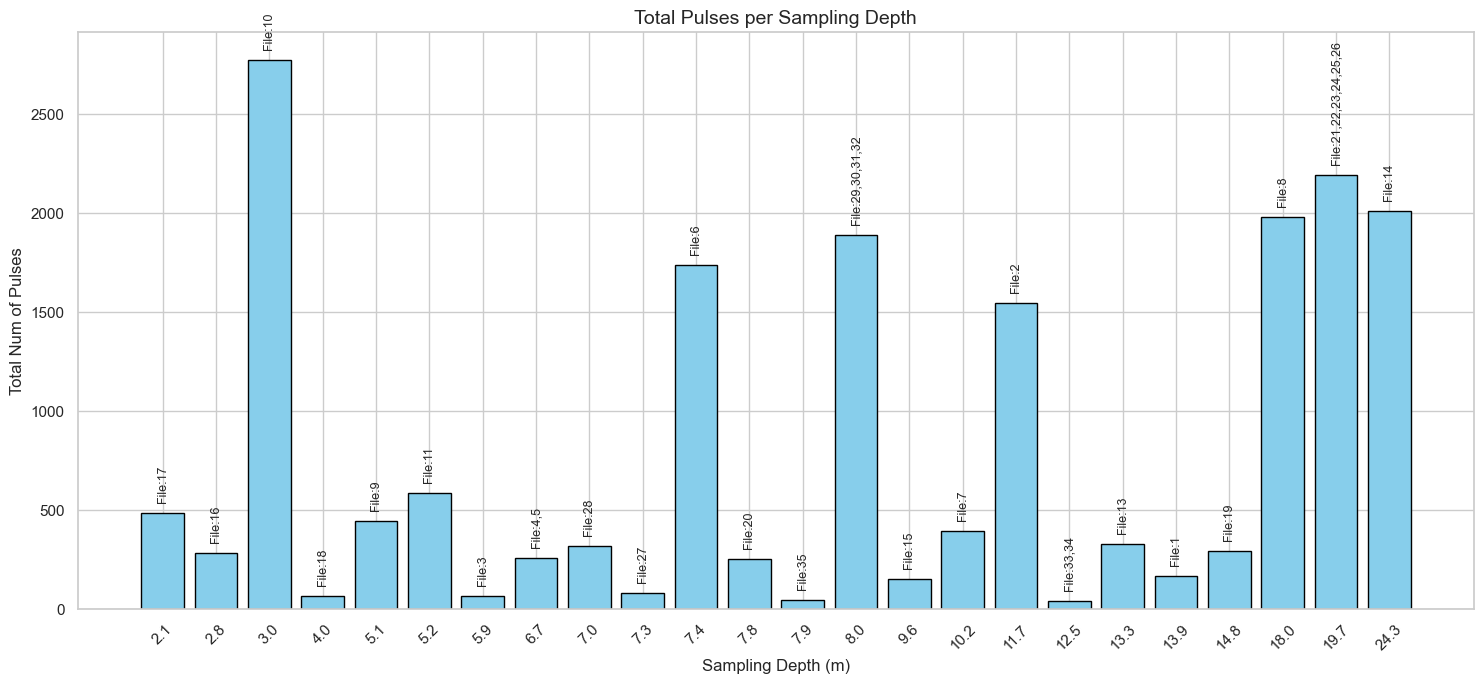

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 设置中文字体（如需要）或美化样式
sns.set_theme(style="whitegrid")

# 1. 定义数据路径
click_trains_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains.csv'

# 2. 定义 Ori_file_num 与 深度的映射关系
depth_dict = {
    1: 13.9, 2: 11.7, 3: 5.9, 4: 6.7, 5: 6.7, 6: 7.4, 7: 10.2, 8: 18, 9: 5.1, 10: 3, 
    11: 5.2, 12: 7.2, 13: 13.3, 14: 24.3, 15: 9.6, 16: 2.8, 17: 2.1, 18: 4, 
    19: 14.8, 20: 7.8, 21: 19.7, 22: 19.7, 23: 19.7, 24: 19.7, 25: 19.7, 26: 19.7, 
    27: 7.3, 28: 7, 29: 8, 30: 8, 31: 8, 32: 8, 33: 12.5, 34: 12.5, 35: 7.9
}

# 3. 加载并清洗 ClickTrains 数据
print("正在处理 Task 1 数据...")
df_trains = pd.read_csv(click_trains_path)

# 强制数值转换
df_trains['Ori_file_num(No.)'] = pd.to_numeric(df_trains['Ori_file_num(No.)'], errors='coerce')
df_trains['Num_of_pulses'] = pd.to_numeric(df_trains['Num_of_pulses'], errors='coerce')

# 映射深度
df_trains['Depth'] = df_trains['Ori_file_num(No.)'].map(depth_dict)

# 按深度聚合：计算脉冲总数，并收集对应的文件编号
# 定义聚合逻辑
agg_func = {
    'Num_of_pulses': 'sum',
    'Ori_file_num(No.)': lambda x: sorted(list(set(x.astype(int))))
}

depth_summary = df_trains.groupby('Depth').agg(agg_func).reset_index()
depth_summary = depth_summary.sort_values('Depth').reset_index(drop=True)

# 4. 绘图
plt.figure(figsize=(15, 7))
bars = plt.bar(depth_summary['Depth'].astype(str), depth_summary['Num_of_pulses'], color='skyblue', edgecolor='black')

# 在柱状图上方标注文件编号
for i, bar in enumerate(bars):
    files = depth_summary.loc[i, 'Ori_file_num(No.)']
    file_label = f"File:{','.join(map(str, files))}"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             file_label, ha='center', va='bottom', rotation=90, fontsize=9)

plt.xlabel('Sampling Depth (m)', fontsize=12)
plt.ylabel('Total Num of Pulses', fontsize=12)
plt.title('Total Pulses per Sampling Depth', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

正在处理 Task 2 数据...


Extracting Train Numbers: 100%|██████████| 18418/18418 [00:00<00:00, 442238.66it/s]
C:\Users\Chico\AppData\Local\Temp\ipykernel_879688\3447065293.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depth', y='ratio', data=df_merged, palette="Set3")


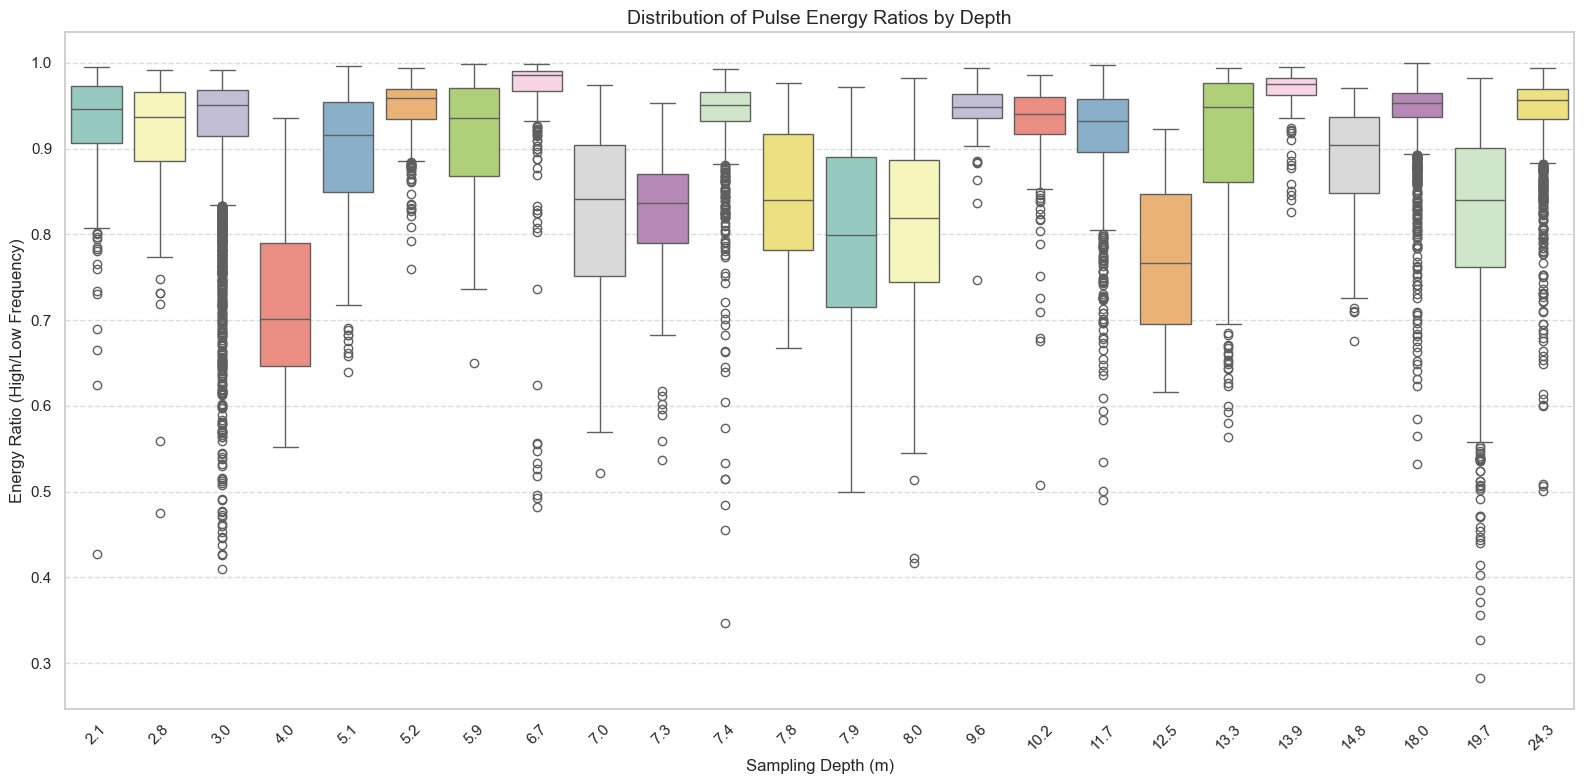

任务完成，Chico。


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 定义数据路径
metadata_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\05_DistinguishbyEnergy\reverberation_metadata.csv'

print("正在处理 Task 2 数据...")

# 2. 读取元数据
df_meta = pd.read_csv(metadata_path)

# 提取 folder 列中的 Train_num (例如 'PulseTrain_001' -> 1)
def extract_train_num(folder_str):
    match = re.search(r'(\d+)', folder_str)
    return int(match.group(1)) if match else None

# 使用进度条处理（虽然数据量不大，但按要求展示）
tqdm.pandas(desc="Extracting Train Numbers")
df_meta['Train_num(No.)'] = df_meta['folder'].progress_apply(extract_train_num)

# 3. 关联 ClickTrains 获取 Ori_file_num
# 我们只需要 ClickTrains 中的 Train_num 和 Ori_file_num 的对应关系
df_train_mapping = df_trains[['Train_num(No.)', 'Ori_file_num(No.)']].drop_duplicates()

# 合并数据
df_merged = pd.merge(df_meta, df_train_mapping, on='Train_num(No.)', how='left')

# 4. 映射深度
df_merged['Depth'] = df_merged['Ori_file_num(No.)'].map(depth_dict)

# 强制数值转换
df_merged['ratio'] = pd.to_numeric(df_merged['ratio'], errors='coerce')
df_merged = df_merged.dropna(subset=['ratio', 'Depth'])

# 5. 按照深度数值从小到大排序绘图
df_merged = df_merged.sort_values('Depth')

plt.figure(figsize=(16, 8))
sns.boxplot(x='Depth', y='ratio', data=df_merged, palette="Set3")

plt.xlabel('Sampling Depth (m)', fontsize=12)
plt.ylabel('Energy Ratio (High/Low Frequency)', fontsize=12)
plt.title('Distribution of Pulse Energy Ratios by Depth', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("任务完成，Chico。")

正在构建深度映射表...
正在读取 PulseParameters.txt 文件...


Processing Folders: 100%|██████████| 832/832 [00:00<00:00, 1316.66it/s]


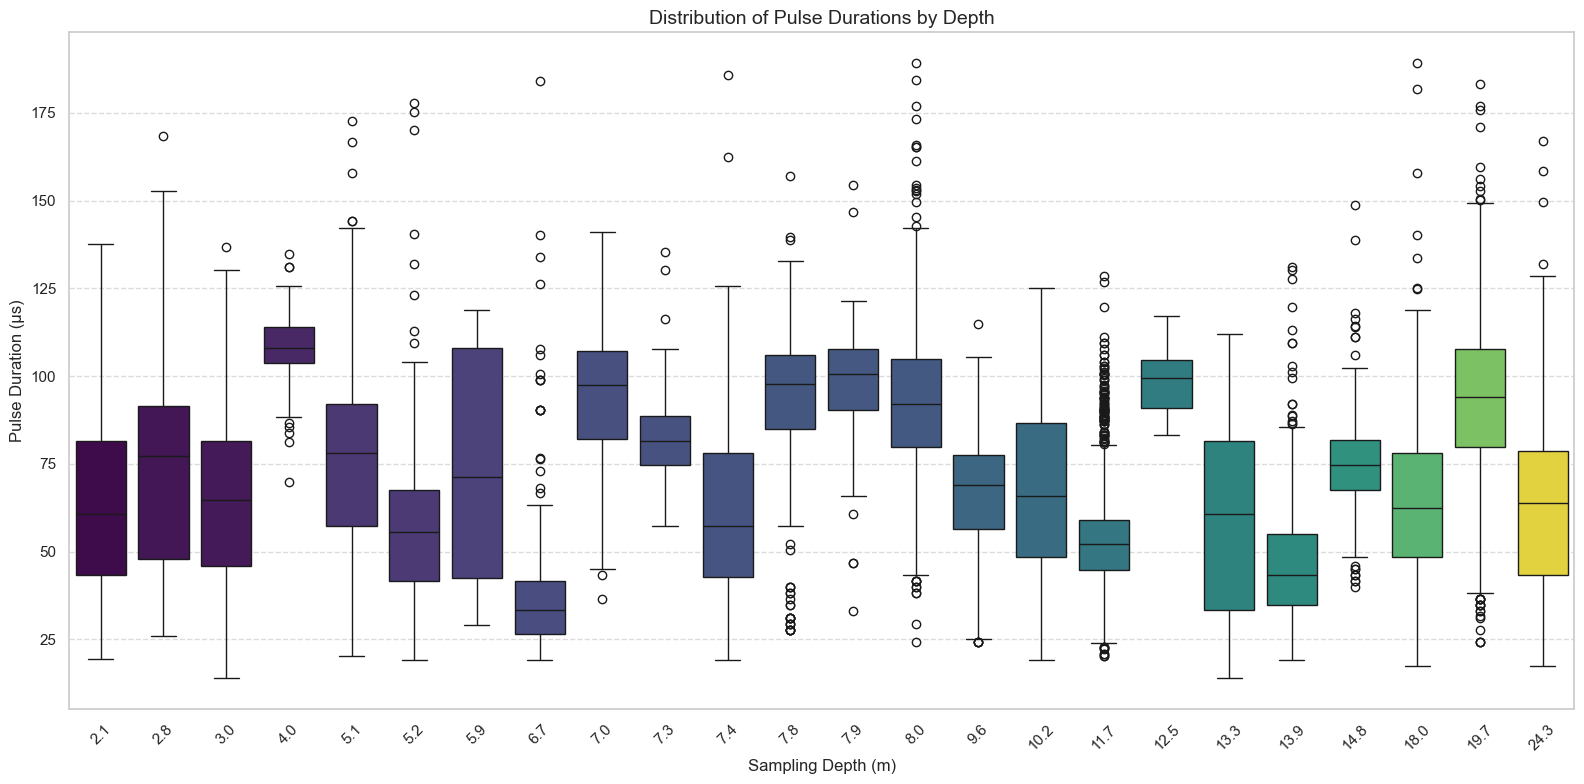

警告已消除，处理完成。


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

# 1. 基础路径定义
base_dir = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains'
click_trains_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains.csv'

# 2. 深度映射关系
depth_dict = {
    1: 13.9, 2: 11.7, 3: 5.9, 4: 6.7, 5: 6.7, 6: 7.4, 7: 10.2, 8: 18, 9: 5.1, 10: 3, 
    11: 5.2, 12: 7.2, 13: 13.3, 14: 24.3, 15: 9.6, 16: 2.8, 17: 2.1, 18: 4, 
    19: 14.8, 20: 7.8, 21: 19.7, 22: 19.7, 23: 19.7, 24: 19.7, 25: 19.7, 26: 19.7, 
    27: 7.3, 28: 7, 29: 8, 30: 8, 31: 8, 32: 8, 33: 12.5, 34: 12.5, 35: 7.9
}

# 3. 构建深度映射表
print("正在构建深度映射表...")
df_trains_info = pd.read_csv(click_trains_path)
df_trains_info['Depth'] = df_trains_info['Ori_file_num(No.)'].map(depth_dict)
train_to_depth = dict(zip(df_trains_info['Train_num(No.)'], df_trains_info['Depth']))

# 4. 循环读取文件
all_duration_data = []
print("正在读取 PulseParameters.txt 文件...")
for train_num in tqdm(range(1, 833), desc="Processing Folders"):
    folder_name = f"PulseTrain_{train_num:03d}"
    file_path = os.path.join(base_dir, folder_name, "PulseParameters.txt")
    
    if os.path.exists(file_path):
        try:
            temp_df = pd.read_csv(file_path, sep='\t')
            if 'Duration(μs)' in temp_df.columns:
                durations = pd.to_numeric(temp_df['Duration(μs)'], errors='coerce').dropna().tolist()
                depth = train_to_depth.get(train_num)
                for d in durations:
                    all_duration_data.append({'Depth': depth, 'Duration': d})
        except Exception:
            pass 

# 5. 整合数据并绘图
df_plot = pd.DataFrame(all_duration_data)
df_plot = df_plot.sort_values('Depth')

plt.figure(figsize=(16, 8))

# 修正部分：将 x 赋值给 hue，并设置 legend=False
sns.boxplot(
    x='Depth', 
    y='Duration', 
    data=df_plot, 
    hue='Depth', 
    palette="viridis", 
    legend=False
)

plt.xlabel('Sampling Depth (m)', fontsize=12)
plt.ylabel('Pulse Duration (μs)', fontsize=12)
plt.title('Distribution of Pulse Durations by Depth', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("警告已消除，处理完成。")

正在读取并预处理 Metadata 数据...
正在读取各文件夹下的 PulseParameters.txt 数据...


Processing TXT Files: 100%|██████████| 832/832 [00:00<00:00, 952.99it/s]


正在合并数据维度...
数据处理完成，共计 18406 条有效脉冲记录。


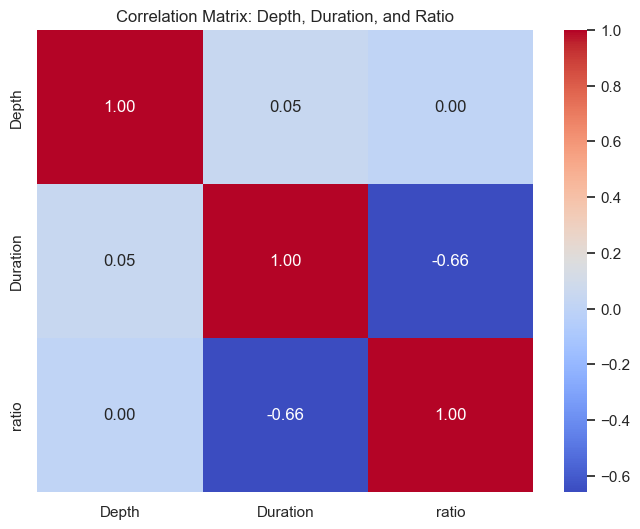

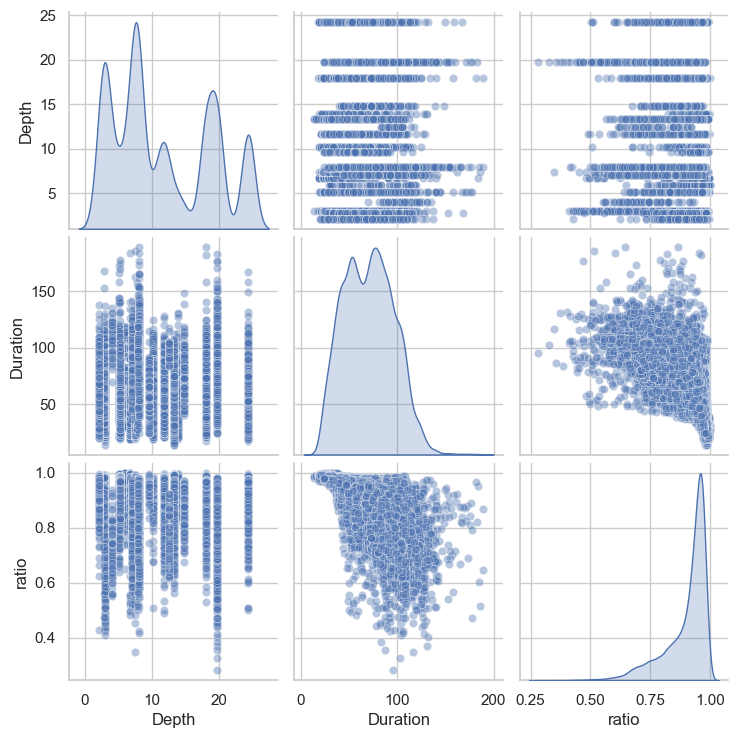

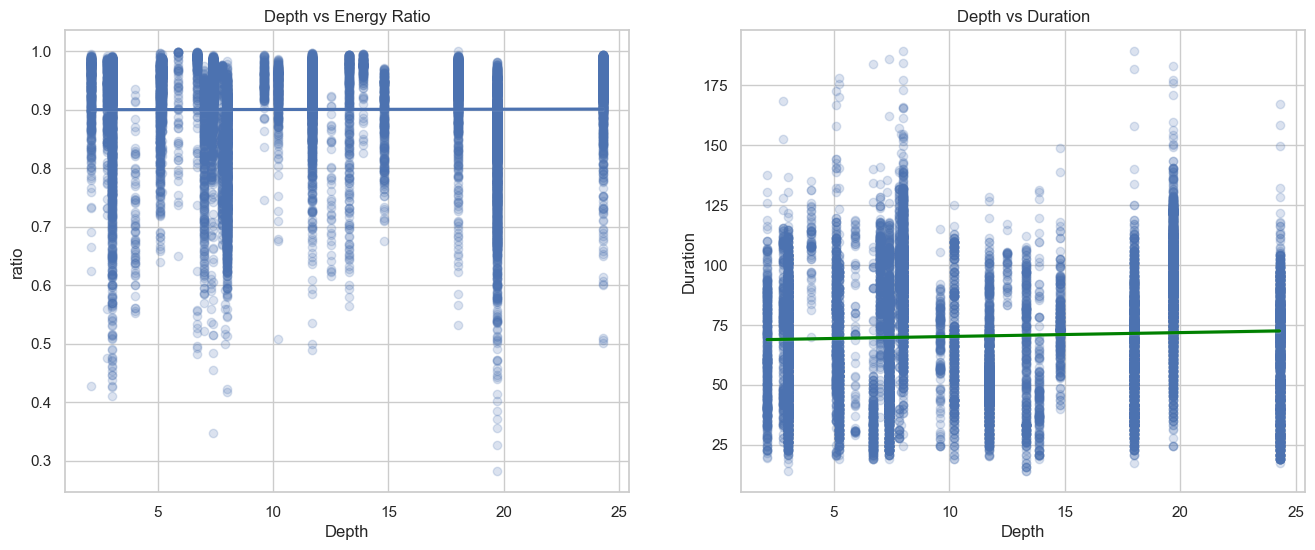

分析完成，Chico。


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from tqdm import tqdm

# 1. 基础路径与映射定义
base_dir = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains'
metadata_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\05_DistinguishbyEnergy\reverberation_metadata.csv'
click_trains_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains.csv'

depth_dict = {
    1: 13.9, 2: 11.7, 3: 5.9, 4: 6.7, 5: 6.7, 6: 7.4, 7: 10.2, 8: 18, 9: 5.1, 10: 3, 
    11: 5.2, 12: 7.2, 13: 13.3, 14: 24.3, 15: 9.6, 16: 2.8, 17: 2.1, 18: 4, 
    19: 14.8, 20: 7.8, 21: 19.7, 22: 19.7, 23: 19.7, 24: 19.7, 25: 19.7, 26: 19.7, 
    27: 7.3, 28: 7, 29: 8, 30: 8, 31: 8, 32: 8, 33: 12.5, 34: 12.5, 35: 7.9
}

# 2. 准备 Metadata 数据
print("正在读取并预处理 Metadata 数据...")
df_meta = pd.read_csv(metadata_path)

def parse_meta_info(row):
    train_match = re.search(r'(\d+)', row['folder'])
    train_num = int(train_match.group(1)) if train_match else None
    pulse_match = re.search(r'Pulse_(\d+)', row['filename'])
    pulse_no = int(pulse_match.group(1)) if pulse_match else None
    return pd.Series([train_num, pulse_no])

df_meta[['Train_num', 'Pulse_No']] = df_meta.apply(parse_meta_info, axis=1)
# 确保 Metadata 中没有重复记录
df_meta = df_meta.drop_duplicates(subset=['Train_num', 'Pulse_No']).reset_index(drop=True)

# 3. 准备 Duration 数据
all_txt_data = []
print("正在读取各文件夹下的 PulseParameters.txt 数据...")
for train_num in tqdm(range(1, 833), desc="Processing TXT Files"):
    folder_name = f"PulseTrain_{train_num:03d}"
    file_path = os.path.join(base_dir, folder_name, "PulseParameters.txt")
    
    if os.path.exists(file_path):
        try:
            temp_df = pd.read_csv(file_path, sep='\t')
            if 'No.Pulse' in temp_df.columns and 'Duration(μs)' in temp_df.columns:
                subset = temp_df[['No.Pulse', 'Duration(μs)']].copy()
                subset['Train_num'] = train_num
                all_txt_data.append(subset)
        except Exception:
            pass

df_duration = pd.concat(all_txt_data, ignore_index=True)
df_duration.rename(columns={'No.Pulse': 'Pulse_No', 'Duration(μs)': 'Duration'}, inplace=True)
# 确保 Duration 中没有重复记录
df_duration = df_duration.drop_duplicates(subset=['Train_num', 'Pulse_No']).reset_index(drop=True)

# 4. 合并所有维度数据
print("正在合并数据维度...")
# inner join 保证 Pulse_No 和 Train_num 在两边都存在
df_combined = pd.merge(df_meta, df_duration, on=['Train_num', 'Pulse_No'], how='inner')
# 重要：合并后重置索引，防止 Index 对象出现重复
df_combined = df_combined.reset_index(drop=True)

# 映射深度
df_trains_info = pd.read_csv(click_trains_path)
df_trains_info['Depth'] = df_trains_info['Ori_file_num(No.)'].map(depth_dict)
# 确保映射表唯一
train_to_depth = df_trains_info.drop_duplicates('Train_num(No.)').set_index('Train_num(No.)')['Depth'].to_dict()

# 安全映射：使用 .map 之前确保 Train_num 类型为 int
df_combined['Train_num'] = df_combined['Train_num'].astype(int)
df_combined['Depth'] = df_combined['Train_num'].map(train_to_depth)

# 5. 最终清洗与分析
df_analysis = df_combined[['Depth', 'Duration', 'ratio']].copy()
df_analysis = df_analysis.apply(pd.to_numeric, errors='coerce').dropna()

print(f"数据处理完成，共计 {len(df_analysis)} 条有效脉冲记录。")

# --- 绘图 ---
# A. 相关性热图
plt.figure(figsize=(8, 6))
corr_matrix = df_analysis.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Depth, Duration, and Ratio')
plt.show()

# B. Pairplot
sns.pairplot(df_analysis, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()

# C. 回归图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(x='Depth', y='ratio', data=df_analysis, ax=ax1, scatter_kws={'alpha':0.2})
ax1.set_title('Depth vs Energy Ratio')
sns.regplot(x='Depth', y='Duration', data=df_analysis, ax=ax2, scatter_kws={'alpha':0.2}, line_kws={'color':'green'})
ax2.set_title('Depth vs Duration')
plt.show()

print("分析完成，Chico。")